In [ ]:
# AMATH 581 HW 4
# Jonathan McCormack 

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl
from sklearn.model_selection import KFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score


In [2]:
# Necessary Functions for Evaluating Models

# Mean Square Error
def mse(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """Compute mean squared error of predictions."""
    return float(np.mean((y_pred - y_true) ** 2))

## Import Data

In [3]:
# Load Training, Validation test, and Unknown test data

# Input features in order: 1.fixed acidity, 2.volatile acidity, 3.citric acid, 4.residual sugar, 5.chlorides
#                          6.free sulfur dioxide, 7.total sulfur dioxide, 8.density, 9.pH, 10.sulphates, 11.alcohol
# Output feature is a quality score between 0 and 10

# Identify current directory and path to data file
print("Current working directory:", Path.cwd())

# load data files
wine_training = np.loadtxt(Path.cwd() / 'wine_training.csv', delimiter=",", unpack=True) # training data
wine_validation = np.loadtxt(Path.cwd() / 'wine_test.csv', delimiter=",", unpack=True) # validation test data
wine_unknown = np.loadtxt(Path.cwd() / 'wine_new_batch.csv', delimiter=",", unpack=True) # unknown test data with unknown output

# Identify the number of samples in each set
training_size = wine_training.shape[1]
validation_size = wine_validation.shape[1]
unknown_size = wine_unknown.shape[1]

# Identify the number of features; the last row is the output score
feature_count = wine_training.shape[0]-1

# We transpose the data so that each column is a feature and each row is a sample
X_train = np.transpose(wine_training[0:feature_count]) # the first 11 rows of the original data are the input features
print(X_train.shape)
Y_train = np.transpose(wine_training[-1]) # the last row of the original data is the output score

X_validate = np.transpose(wine_validation[0:feature_count])
print(X_validate.shape)
Y_validate = np.transpose(wine_validation[-1])

X_unknown = np.transpose(wine_unknown[0:feature_count])
print(X_unknown.shape)

# we inherently don't have a output row for the unknown test data

del wine_training, wine_validation, wine_unknown


Current working directory: /home/jrmccormack20/Desktop/Code Repositories/AMATH 582/AMATH_582_Project_4
(1115, 11)
(479, 11)
(5, 11)


## Preprocess and Display Data

In [4]:
# Center and Normalize input feature data

# Normalized data = (data - mean)/ standard deviation
# Mean and Standard deviation is calculated with axis 0 because we average like features

X_train_means = np.mean(X_train, axis=0)
X_train_stds = np.std(X_train, axis=0)
X_train_normal = (X_train - np.matlib.repmat(X_train_means, training_size, 1))/np.matlib.repmat(X_train_stds, training_size, 1)
print(X_train_normal.shape)

# Add a ones column to the left of the data matrix to ensure Least Squares finds an intercept coefficient
A_train = np.concatenate((np.ones((X_train_normal.shape[0],1)), X_train_normal), axis = 1)
print(A_train.shape)

# Similarly Normalize and add intercept column to the validation test data
X_validate_means = np.mean(X_validate, axis=0)
X_validate_stds = np.std(X_validate, axis=0)
X_validate_normal = (X_validate - np.matlib.repmat(X_validate_means, validation_size, 1))/np.matlib.repmat(X_validate_stds, validation_size, 1)
print(X_validate_normal.shape)
A_validate = np.concatenate((np.ones((X_validate_normal.shape[0],1)), X_validate_normal), axis = 1)
print(A_validate.shape)

# Similarly Normalize and add intercept column to the unknown test data
X_unknown_means = np.mean(X_unknown, axis=0)
X_unknown_stds = np.std(X_unknown, axis=0)
X_unknown_normal = (X_unknown - np.matlib.repmat(X_unknown_means, unknown_size, 1))/np.matlib.repmat(X_unknown_stds, unknown_size, 1)
print(X_unknown_normal.shape)
A_unknown= np.concatenate((np.ones((X_unknown_normal.shape[0],1)), X_unknown_normal), axis = 1)
print(A_unknown.shape)

# Note: we will not normalize the output data, but we will use one-hot encoding

del X_train, X_train_means, X_train_stds, X_validate, X_validate_means, X_validate_stds, X_validate_normal, X_unknown, X_unknown_means, X_unknown_stds, X_unknown_normal


(1115, 11)
(1115, 12)
(479, 11)
(479, 12)
(5, 11)
(5, 12)


In [5]:
# Implement one hot encoding on output arrays

# We know the output is from 0 to 10, therefore we made a 11x11 Identity matrix 
# and indexed the rows of that matrix using the value of the output array

Y_train_encoded = np.eye(11, dtype=int)[Y_train.astype(int)]
Y_validate_encoded = np.eye(11, dtype=int)[Y_validate.astype(int)]

print(Y_train_encoded.shape, Y_validate_encoded.shape)


(1115, 11) (479, 11)


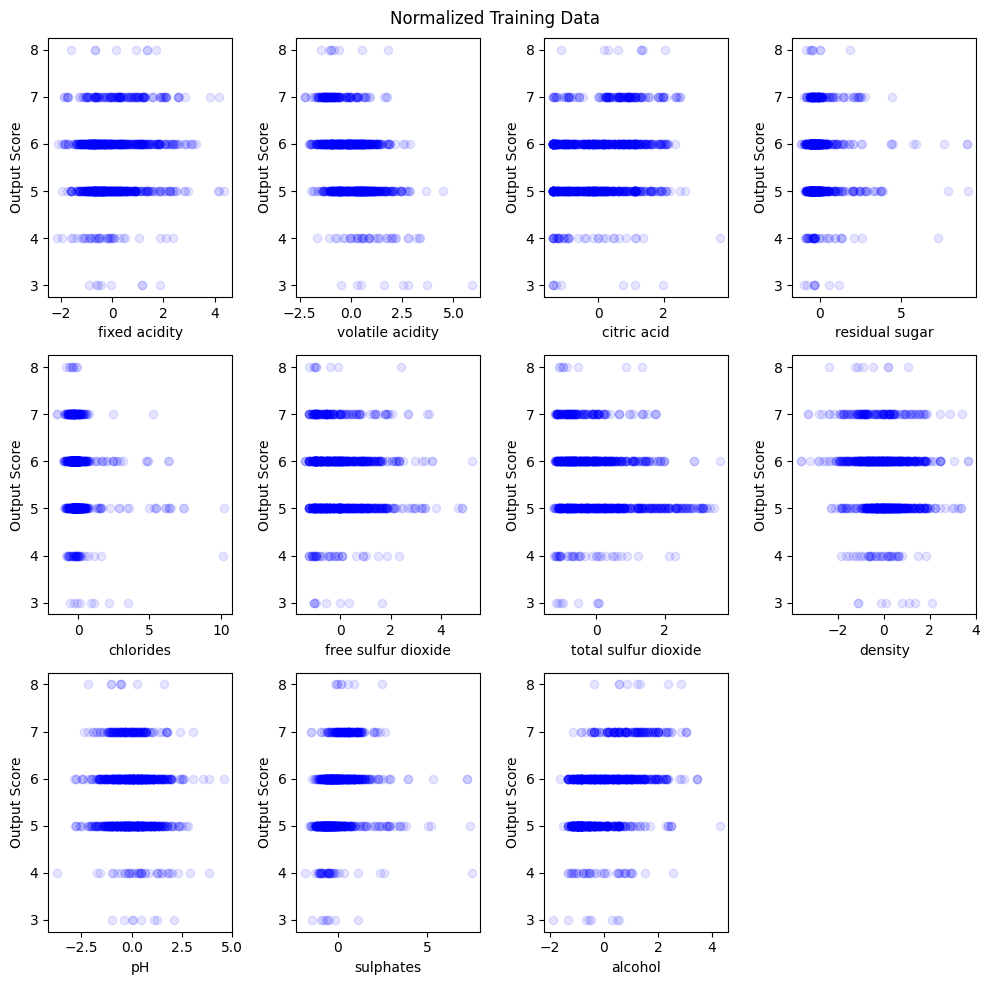

In [6]:
# Plot Scatter plot for training and validation test data sets to show relation between certain factors and certain output levels

features = ['fixed acidity','volatile acidity','citric acid','residual sugar', 
          'chlorides','free sulfur dioxide','total sulfur dioxide','density','pH', 
          'sulphates','alcohol']

fig = plt.figure(figsize=(10,10))
fig.suptitle('Normalized Training Data')
for i, feature in enumerate(features):
    xlabel = feature
    plt.subplot(3, 4, i+1)
    plt.scatter(X_train_normal[:,i], Y_train, c='b', alpha=0.1) # training data
    plt.ylabel('Output Score', fontsize=10)
    plt.xlabel(str(xlabel), fontsize=10)
    plt.tight_layout()
plt.savefig("Figure 1.png", dpi=300)
plt.show()

del features, fig, i, feature, xlabel, X_train_normal


## Affine/Linear Regression

Theta array is (12, 11)
Ordinary Linear Least Squares Training MSE = 0.49417040358744396
Ordinary Linear Least Squares Validation MSE = 0.6263048016701461


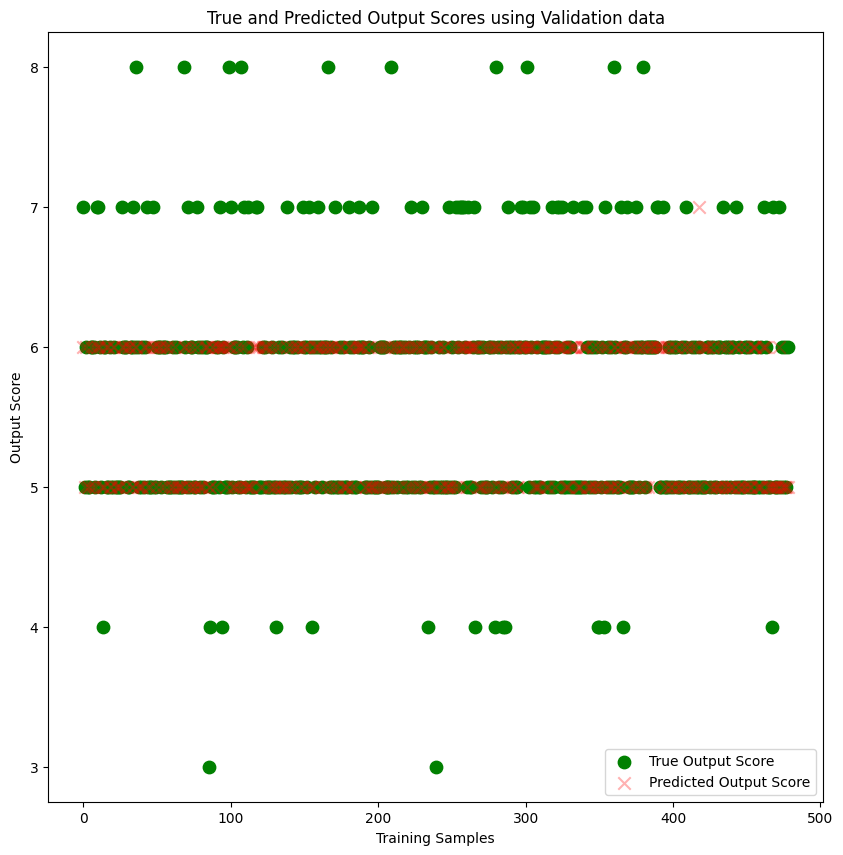

In [7]:
# Linear regression for encoded data without regularization or cross validation

# Least Squares to solve for the theta (coefficient) vector
sol = np.linalg.lstsq(A_train, Y_train_encoded, rcond=None )
linear_theta = sol[0]
print('Theta array is', linear_theta.shape)

# Predicted Output Score using the model theta vector applied to the training test data
Y_train_est = A_train @ linear_theta
Y_train_est = np.argmax(Y_train_est, axis=1)

# Predicted Output Score using the model theta vector applied to the validation test data
Y_validate_est = A_validate @ linear_theta
Y_validate_est = np.argmax(Y_validate_est, axis=1)

# Evaluate ordinary linear least squares model using MSE
print('Ordinary Linear Least Squares Training MSE =', mse(y_pred=Y_train_est, y_true=Y_train))
print('Ordinary Linear Least Squares Validation MSE =', mse(y_pred=Y_validate_est, y_true=Y_validate))

# Plot Predicted Output and True Output data
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.scatter(range(A_validate.shape[0]), Y_validate, s= 80, marker='o', c='g', label='True Output Score')
ax.scatter(range(A_validate.shape[0]), Y_validate_est, s=80, marker='x', c='r', alpha=0.3, label='Predicted Output Score')
ax.set_xlabel('Training Samples')
ax.set_ylabel('Output Score')
ax.set_title('True and Predicted Output Scores using Validation data')
ax.legend()
plt.savefig("Figure 2.png", dpi=300)
plt.show()

del sol, Y_train_est, Y_validate_est, fig, ax


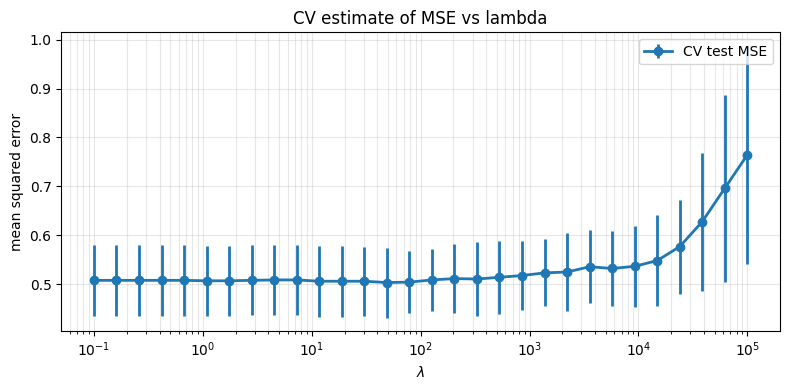

In [8]:
# Linear regression for encoded data using k-fold cross validation and ridge regression

# Linear Ridge Regression
def ridge_regression(X, y, lam):
    """Calculates theta vector using the closed-form solution: (X^T * X + lambda * I) * (theta) = X^T * Y """
    """Input X array must already include a ones column for the intercept coefficient on the left side"""
    
    # Creates an Identity matrix for all input featurs, but zeros out the coefficient for the intercept (first) column
    n_features = X.shape[1]
    I = np.identity(n_features)
    I[0, 0] = 0 
    
    # Solve (X^T * X + lambda * I) * (theta) = X^T * Y for theta
    A = X.T @ X + lam * I
    B = X.T @ y
    theta = np.linalg.solve(A, B)
    return theta

n_folds = 10
n_lambdas = 30
lambdas = np.logspace(-1, 5, n_lambdas)

# CV_MSE matrix stores cross validation score for different hyperparameter combinations
CV_MSE = np.zeros((n_folds, n_lambdas), dtype=float)

# Use KFold from sklearn.model_selection to produce a KFold object which will split the data into n_folds subsets of randomized samples
kf = KFold(n_splits=n_folds, shuffle=True, random_state=0)

# Iterate over each k fold and each value of lambda to calculate the optimal hyperparameter lambda
for k, (train_indice, test_indice) in enumerate(kf.split(A_train)):

    # extract train/test splits for this fold; these splits only come from the original training data not the validation test data
    X_train_cv, Y_train_cv = A_train[train_indice], Y_train_encoded[train_indice]
    X_test_cv, Y_test_cv = A_train[test_indice], Y_train[test_indice]

    for i, lam in enumerate(lambdas):
        
        # Use the above linear ridge regression to calculate the theta vector
        theta = ridge_regression(X_train_cv, Y_train_cv, lam)
        
        # Use the theta vector to estimate the output scores of the cross validation test set
        y_test_cv_est = X_test_cv @ theta
        y_test_cv_est = np.argmax(y_test_cv_est, axis=1)
        
        # Score the current iteration of cross validation using MSE
        cv_test_mse = mse(y_pred=y_test_cv_est, y_true=Y_test_cv)
        
        # Store test MSEs in a matrix of shape (num_folds, num_lambdas) for later analysis
        CV_MSE[k,i] = cv_test_mse 
    
# Compute mean and std of test MSEs across folds for each lambda
mean_mse = np.mean(CV_MSE, axis=0)
std_mse = np.std(CV_MSE, axis=0)

# Plot mean test MSE with error bars showing std across folds
plt.figure(figsize=(8, 4))
plt.errorbar(lambdas, mean_mse, yerr=std_mse, fmt="o-", lw=2, label="CV test MSE")
plt.xscale('log')
plt.xlabel(r"$\lambda$")
plt.ylabel("mean squared error")
plt.title("CV estimate of MSE vs lambda")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Figure 3.png", dpi=300)
plt.show()

del n_folds, n_lambdas, lambdas, CV_MSE, kf, k, train_indice, test_indice, X_train_cv, X_test_cv, Y_train_cv, Y_test_cv, i, lam, theta, y_test_cv_est, cv_test_mse, mean_mse, std_mse


## Gaussian Kernel

In [9]:

# range of values to try 
n_sigmas = 5
n_lambdas = 5
n_folds = 5


sigmas = np.logspace(0.5, 2.5, n_sigmas, base=2)
lambdas = np.logspace(-1.5, 0.5, n_lambdas, base=2)

cv_scores = np.zeros((n_sigmas, n_lambdas))

RBF_KRR_CV = KernelRidge(kernel='rbf')

for i in range(n_sigmas):

    RBF_KRR_CV.gamma = 1/(2*((sigmas[i])**2))

    for j in range(n_lambdas): 

        RBF_KRR_CV.alpha = (lambdas[j])
        
        cv_score = cross_val_score(RBF_KRR_CV, A_train, Y_train_encoded, scoring= 'neg_mean_squared_error', cv=n_folds)

        cv_scores[i,j] = (np.mean(cv_score))

In [10]:
indice_max = np.array( np.where( cv_scores == cv_scores.max() ), dtype=int).flatten()

print(indice_max)
print(sigmas[indice_max[0]])
print(lambdas[indice_max[1]])

print(cv_scores.max())

RBF_improved_gamma = 1/(2*((sigmas[indice_max[0]])**2))
RBF_improved_alpha = (lambdas[indice_max[1]])
print('RBF improved gamma =', RBF_improved_gamma)
print('RBF improved alpha =', RBF_improved_alpha)



[1 3]
2.0
1.0
-0.046299644631811146
RBF improved gamma = 0.125
RBF improved alpha = 1.0


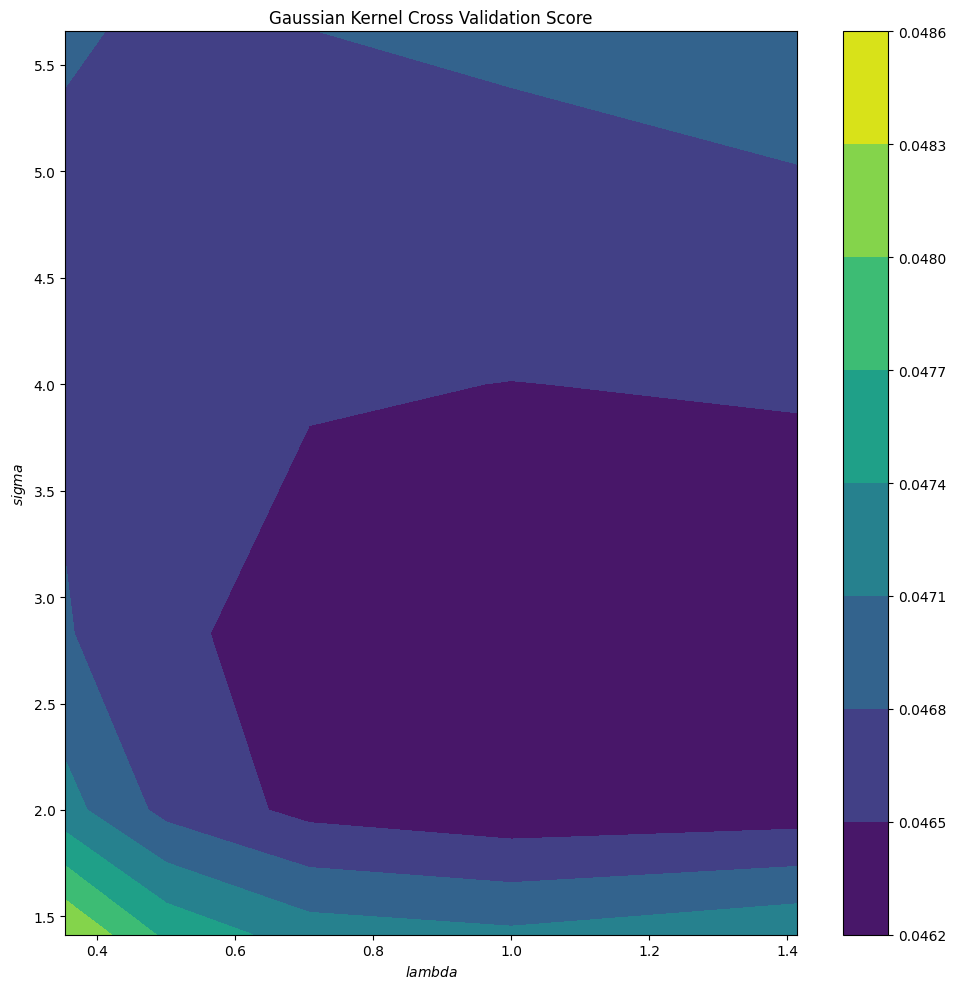

In [11]:
lv, sv = np.meshgrid(lambdas, sigmas)

fig, ax = plt.subplots(figsize=(10,10))

cv = ax.contourf( lv, sv, np.abs(cv_scores))
ax.set_xlabel('$lambda$')
ax.set_ylabel('$sigma$')
ax.set_title('Gaussian Kernel Cross Validation Score')
fig.colorbar(cv)
plt.savefig("Figure 4.png", dpi=300)

fig.tight_layout()

In [12]:
RBF_KRR = KernelRidge(kernel='rbf', alpha = RBF_improved_alpha, gamma=RBF_improved_gamma)

RBF_KRR.fit(A_train, Y_train_encoded)
RBF_train_predict = RBF_KRR.predict(A_train)
RBF_train_predict = np.argmax(RBF_train_predict, axis=1)
RBF_validate_predict = RBF_KRR.predict(A_validate)
RBF_validate_predict = np.argmax(RBF_validate_predict, axis=1)

RBF_train_mse = mse(y_pred=RBF_train_predict, y_true=Y_train)
RBF_validate_mse = mse(y_pred=RBF_validate_predict, y_true=Y_validate)

print(RBF_train_mse)
print(RBF_validate_mse)

0.2986547085201794
0.5636743215031316


## Laplacian Kernel

In [13]:

# range of values to try 
n_sigmas = 7
n_lambdas = 5
n_folds = 5

sigmas = np.linspace(2, 4, n_sigmas)
lambdas = np.logspace(-4, -1.5, n_lambdas, base=2)

cv_scores = np.zeros((n_sigmas, n_lambdas))

Lap_KRR_CV = KernelRidge(kernel='laplacian')

for i in range(n_sigmas):

    Lap_KRR_CV.gamma = 1/(sigmas[i])

    for j in range(n_lambdas): 

        Lap_KRR_CV.alpha = (lambdas[j])
        
        cv_score = cross_val_score(Lap_KRR_CV, A_train, Y_train_encoded, scoring= 'neg_mean_squared_error', cv=n_folds)

        cv_scores[i,j] = (np.mean(cv_score))


In [14]:
indice_max_max = np.array( np.where( cv_scores == cv_scores.max() ), dtype=int).flatten()

print(indice_max)
print(sigmas[indice_max[0]])
print(lambdas[indice_max[1]])

print(cv_scores.max())

Lap_improved_gamma = 1/(2**sigmas[indice_max[0]])
Lap_improved_alpha = (lambdas[indice_max[1]])
print('RBF improved gamma =', Lap_improved_gamma)
print('RBF improved alpha =', Lap_improved_alpha)



[1 3]
2.3333333333333335
0.2292510108011678
-0.04126678125277269
RBF improved gamma = 0.19842513149602492
RBF improved alpha = 0.2292510108011678


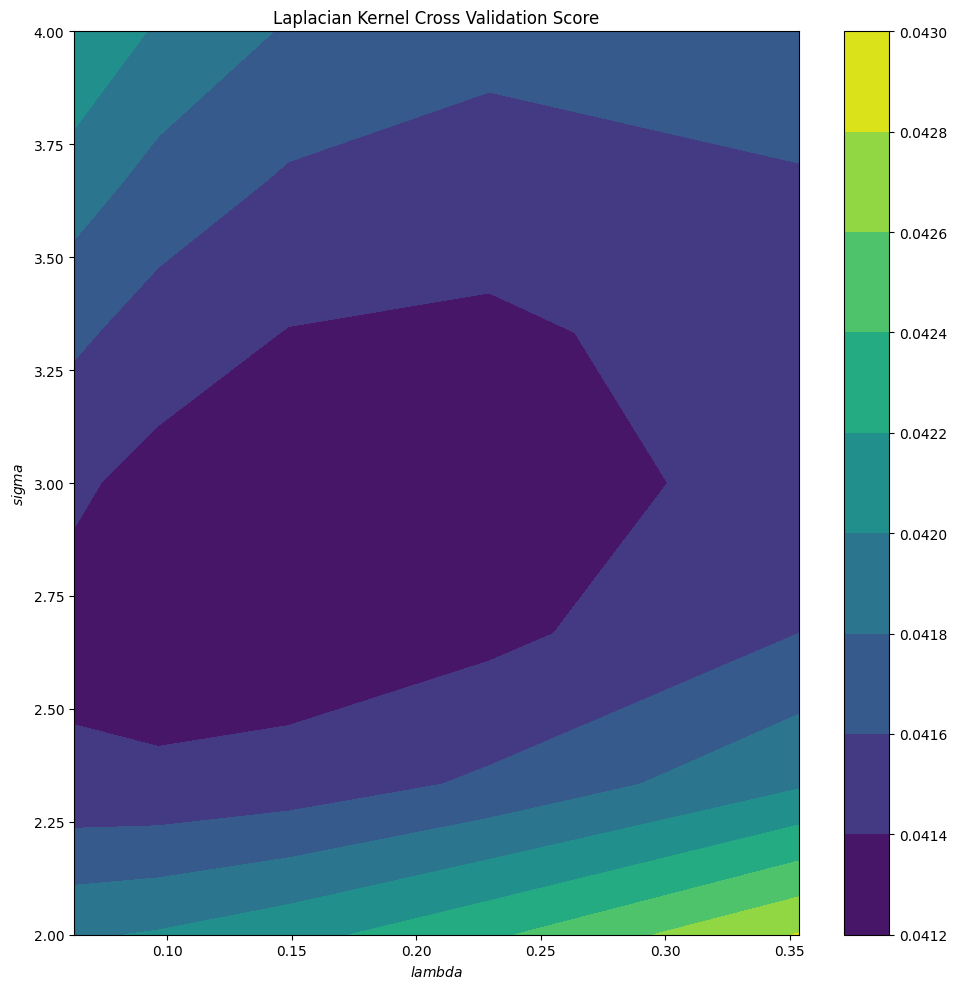

In [15]:
lv, sv = np.meshgrid(lambdas, sigmas)

fig, ax = plt.subplots(figsize=(10,10))

cv = ax.contourf( lv, sv, np.abs(cv_scores))
ax.set_xlabel('$lambda$')
ax.set_ylabel('$sigma$')
ax.set_title('Laplacian Kernel Cross Validation Score')
fig.colorbar(cv)
plt.savefig("Figure 5.png", dpi=300)
fig.tight_layout()

In [16]:
Lap_KRR = KernelRidge(kernel='laplacian', alpha = Lap_improved_alpha, gamma=Lap_improved_gamma)

Lap_KRR.fit(A_train, Y_train_encoded)
Lap_train_predict = RBF_KRR.predict(A_train)
Lap_train_predict = np.argmax(Lap_train_predict, axis=1)
Lap_validate_predict = RBF_KRR.predict(A_validate)
Lap_validate_predict = np.argmax(Lap_validate_predict, axis=1)

Lap_train_mse = mse(y_pred=Lap_train_predict, y_true=Y_train)
Lap_validate_mse = mse(y_pred=Lap_validate_predict, y_true=Y_validate)

print(Lap_train_mse)
print(Lap_validate_mse)

0.2986547085201794
0.5636743215031316


## Polynomial Kernel

In [17]:

n_folds=5

Poly_KRR_CV = KernelRidge(kernel='poly')

param_grid = {
    'alpha': np.linspace(0, 1, 5),
    'coef0': [0, 1],
    'degree': [2, 3, 4, 5],
    'gamma': np.linspace(0, 0.2,5)
}

# Initialize GridSearchCV
Poly_grid_search = GridSearchCV(Poly_KRR_CV, param_grid=param_grid, scoring='neg_mean_squared_error', cv=n_folds)

# Assuming X (features) and y (target) are already defined
Poly_grid_search.fit(A_train, Y_train_encoded)

# Print the best parameters found
print("Best parameters found: ", Poly_grid_search.best_params_)

Poly_improved_alpha, Poly_improved_coef0, Poly_improved_degree, Poly_improved_gamma = Poly_grid_search.best_params_.values()
print(Poly_improved_alpha)
print(Poly_improved_coef0)
print(Poly_improved_degree)
print(Poly_improved_gamma)




/home/jrmccormack20/Desktop/Code Repositories/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/jrmccormack20/Desktop/Code Repositories/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/jrmccormack20/Desktop/Code Repositories/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/jrmccormack20/Desktop/Code Repositories/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/jrmccormack20/Desktop/Code Repositories/.venv/lib64/python3.14/site-packages/sklea

Best parameters found:  {'alpha': np.float64(1.0), 'coef0': 1, 'degree': 2, 'gamma': np.float64(0.05)}
1.0
1
2
0.05


In [18]:
Poly_KRR = KernelRidge(kernel='poly', alpha = Poly_improved_alpha, coef0 = Poly_improved_coef0, degree = Poly_improved_degree, gamma = Poly_improved_gamma)

Poly_KRR.fit(A_train, Y_train_encoded)
Poly_train_predict = Poly_KRR.predict(A_train)
Poly_train_predict = np.argmax(Poly_train_predict, axis=1)
Poly_validate_predict = Poly_KRR.predict(A_validate)
Poly_validate_predict = np.argmax(Poly_validate_predict, axis=1)

Poly_train_mse = mse(Poly_train_predict, Y_train)
Poly_validate_mse = mse(Poly_validate_predict, Y_validate)

print(Poly_train_mse)
print(Poly_validate_mse)

0.4493273542600897
0.5407098121085595


## Applying the different models to the unknown test 

In [19]:
print('linear regression found the unknown values to be:', np.argmax(A_unknown @ linear_theta, axis=1))

RBF_unknown_predict = RBF_KRR.predict(A_unknown)
RBF_unknown_predict = np.argmax(RBF_unknown_predict, axis=1)
print('gaussian kernel regression found the unknown values to be:', RBF_unknown_predict)

Lap_unknown_predict = Lap_KRR.predict(A_unknown)
Lap_unknown_predict = np.argmax(Lap_unknown_predict, axis=1)
print('laplacian kernel regression found the unknown values to be:', Lap_unknown_predict)

Poly_unknown_predict = Poly_KRR.predict(A_unknown)
Poly_unknown_predict = np.argmax(Poly_unknown_predict, axis=1)
print('polynomial kernel regression found the unknown values to be:', Poly_unknown_predict)

linear regression found the unknown values to be: [6 5 6 6 6]
gaussian kernel regression found the unknown values to be: [6 5 5 5 6]
laplacian kernel regression found the unknown values to be: [7 5 6 5 5]
polynomial kernel regression found the unknown values to be: [6 5 6 6 6]
